In [1]:
import sys, os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

In [ ]:
# # --- GPU + Mixed Precision Setup (start cell) ---
# import tensorflow as tf
# from tensorflow.keras import mixed_precision

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     print(f"GPU detected: {gpus[0].name}")
# else:
#     print("GPU NOT detected — TensorFlow will run on CPU")

# mixed_precision.set_global_policy("mixed_float16")
# print("Mixed precision enabled (mixed_float16)")

# print(f"TensorFlow version: {tf.__version__}")
# print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
# print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

In [2]:
data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)


In [3]:
labels = mgr.one_hot()
print(f"Labels shape: {labels.shape}")

Labels shape: (14975, 10)


In [4]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (11980, 150, 150, 1), Test shape: (2995, 150, 150, 1)


In [5]:
import numpy as np
X_train_lstm = X_train.squeeze(axis=-1)  # Usuń ostatni wymiar (kanał)
X_test_lstm = X_test.squeeze(axis=-1)
print(f"LSTM input shape - Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")

LSTM input shape - Train: (11980, 150, 150), Test: (2995, 150, 150)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import backend as K

input_shape = (150, 150)
input_layer = Input(shape=input_shape)

# LSTM Layers (Bidirectional)
lstm_layer = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(input_layer)
lstm_layer = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(lstm_layer)

# Attention Mechanism
attention = layers.Dense(1, activation='tanh')(lstm_layer)
attention = layers.Flatten()(attention)
attention = layers.Activation('softmax')(attention)
attention = layers.RepeatVector(128)(attention)
attention = layers.Permute((2, 1))(attention)
attention = layers.Multiply()([lstm_layer, attention])
attention = layers.Lambda(lambda x: K.sum(x, axis=1))(attention)

# Convolutional Layer
conv_layer = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(lstm_layer)

# Dense Layers
dense_layer = layers.Dense(64, activation='relu')(conv_layer)
dropout_layer = layers.Dropout(0.2)(dense_layer)
dense_layer = layers.Dense(32, activation='relu')(dropout_layer)
dropout_layer = layers.Dropout(0.2)(dense_layer)
global_avg_pool = layers.GlobalAveragePooling1D()(dense_layer)

# Output Layer
merged = layers.Concatenate()([attention, global_avg_pool])
output_layer = layers.Dense(10, activation='softmax')(merged)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 150, 150)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 150, 256)  │    285,696 │ input_layer_11[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 150, 128)  │    164,352 │ bidirectional_6[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 150, 1)    │        129 │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 150)       │          0 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 150)       │          0 │ flatten_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 150, 32)   │     20,512 │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 128, 150)  │          0 │ activation_2[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 150, 64)   │      2,112 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_2 (Permute) │ (None, 150, 128)  │          0 │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 150, 64)   │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 150, 128)  │          0 │ bidirectional_7[… │
│ (Multiply)          │                   │            │ permute_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 150, 32)   │      2,080 │ dropout_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dense_36[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 10)        │      1,610 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 476,491 (1.82 MB)

 Trainable params: 476,491 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(
    X_train_lstm, Y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - accuracy: 0.3464 - loss: 1.7904 - val_accuracy: 0.4257 - val_loss: 1.5935
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step - accuracy: 0.4571 - loss: 1.4948 - val_accuracy: 0.4649 - val_loss: 1.4675
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 33s 109ms/step - accuracy: 0.5065 - loss: 1.3525 - val_accuracy: 0.4825 - val_loss: 1.4107
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 105ms/step - accuracy: 0.5533 - loss: 1.2232 - val_accuracy: 0.5125 - val_loss: 1.3424
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - accuracy: 0.5977 - loss: 1.1027 - val_accuracy: 0.5484 - val_loss: 1.2402
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.6417 - loss: 1.0048 - val_accuracy: 0.5768 - val_loss: 1.1997
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.6709 - loss: 0.9184 - val_accuracy: 0.5680 - val_loss: 1.2484
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 106ms/step - accuracy: 0.7048 - loss: 0

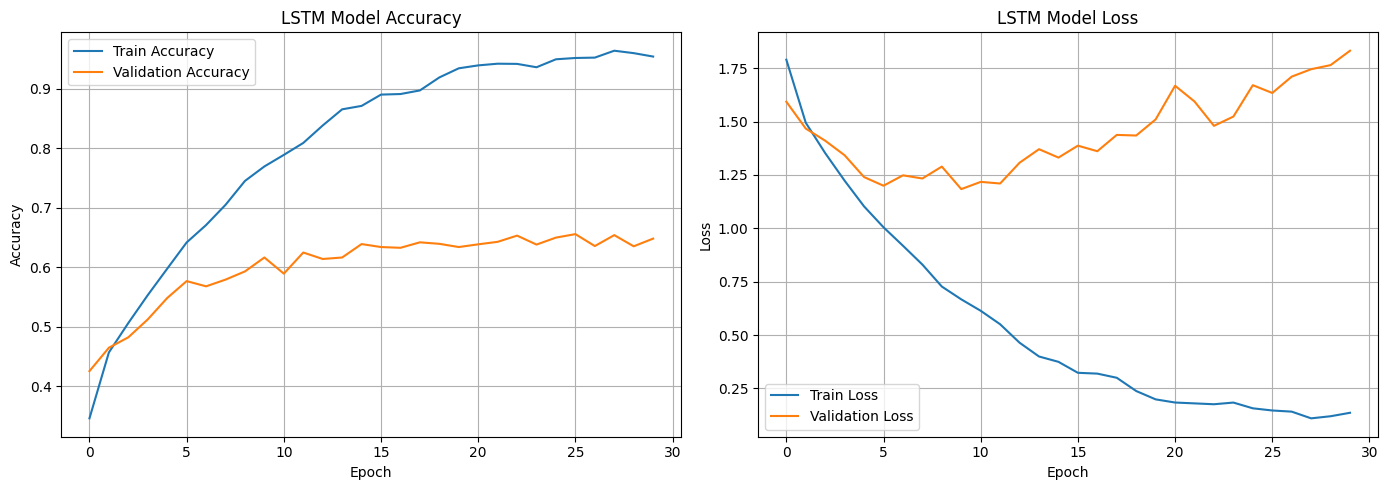

In [31]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('LSTM Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('LSTM Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [32]:
test_loss, test_acc = model.evaluate(X_test_lstm, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6611 - loss: 1.7222

Dokładność na zbiorze testowym: 66.11%
Strata na zbiorze testowym: 1.7222


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


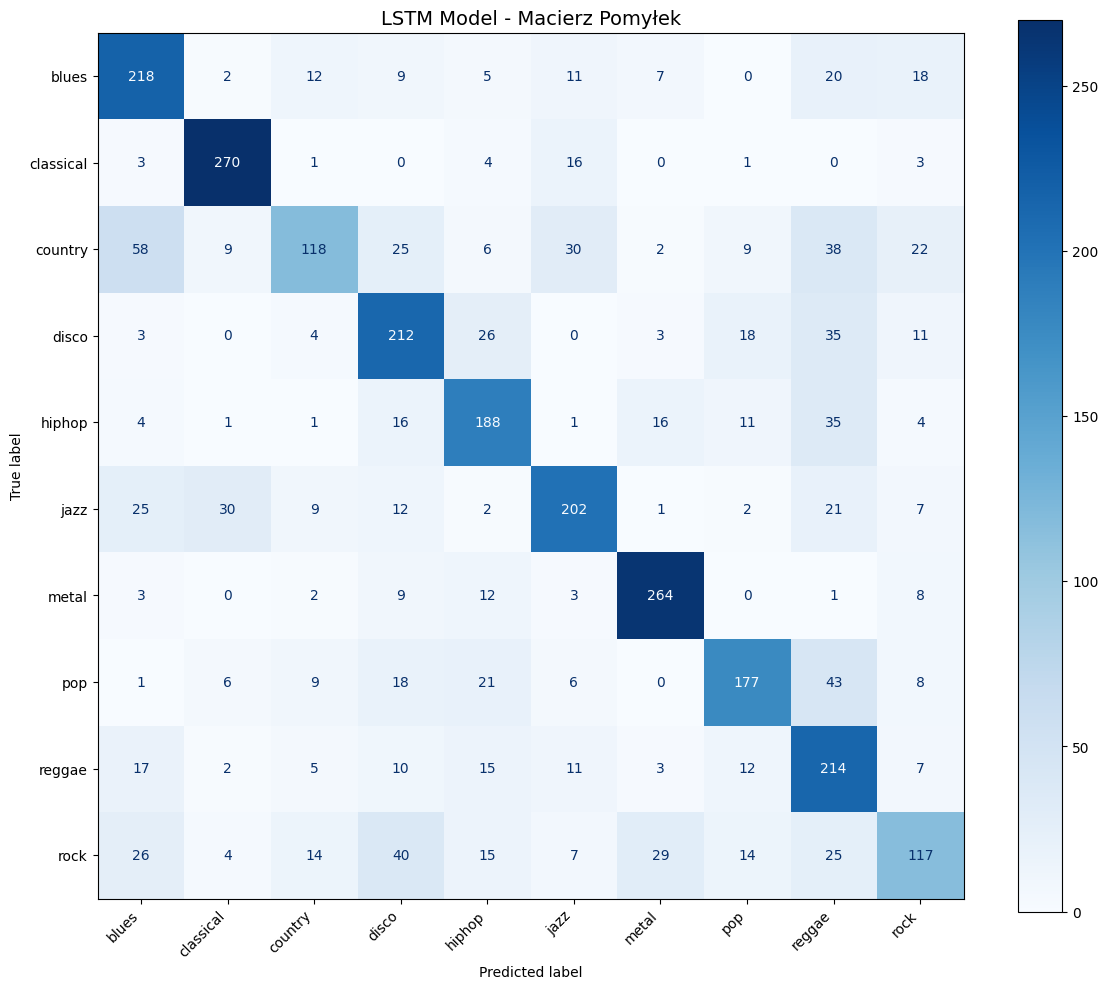


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.61      0.72      0.66       302
   classical       0.83      0.91      0.87       298
     country       0.67      0.37      0.48       317
       disco       0.60      0.68      0.64       312
      hiphop       0.64      0.68      0.66       277
        jazz       0.70      0.65      0.68       311
       metal       0.81      0.87      0.84       302
         pop       0.73      0.61      0.66       289
      reggae       0.50      0.72      0.59       296
        rock       0.57      0.40      0.47       291

    accuracy                           0.66      2995
   macro avg       0.67      0.66      0.65      2995
weighted avg       0.67      0.66      0.65      2995



In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Y_pred_proba = model.predict(X_test_lstm)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(12, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('LSTM Model - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [34]:
model.save('../models/lstm_model.keras')
print("Model zapisany jako: ../models/lstm_model.keras")

Model zapisany jako: ../models/lstm_model.keras
